In [2]:
import sys
import os

# go to correct folder
%cd /workspace/A4-RPiMS/vismatch-main

# install requirements
!pip install -r requirements.txt

# fix version issue + install vismatch
os.environ["SETUPTOOLS_SCM_PRETEND_VERSION_FOR_VISMATCH"] = "0.0.0"
!pip install -e . --no-deps

# install core libs
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install opencv-python yacs huggingface_hub kornia einops matplotlib tqdm

[Errno 2] No such file or directory: '/workspace/A4-RPiMS/vismatch-main'
/workspace/A4-RPiMS/lightGlue
  Using cached torchvision-0.19.1-cp38-cp38-manylinux1_x86_64.whl (7.0 MB)
  Using cached transforms3d-0.4.2-py3-none-any.whl (1.4 MB)
  Using cached kornia_moons-0.2.9-py3-none-any.whl (15 kB)
  Using cached gdown-5.2.2-py3-none-any.whl (18 kB)
  Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (471 kB)
  Using cached imageio-2.35.1-py3-none-any.whl (315 kB)
  Using cached tensorboard-2.14.0-py3-none-any.whl (5.5 MB)
  Using cached scipy-1.10.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.5 MB)
  Using cached trimesh-4.12.2-py3-none-any.whl (741 kB)
  Using cached e2cnn-0.2.3-py3-none-any.whl (225 kB)
  Using cached scikit_image-0.21.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.9 MB)
  Using cached py3_wget-1.0.13-py3-none-any.whl (11 kB)
  Using cached roma-1.5.6-py3-none-any.whl (25 kB)
  Using cached loguru-0

Obtaining file:///workspace/A4-RPiMS/lightGlue
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
ERROR: Package 'vismatch' requires a different Python: 3.8.13 not in '>=3.10'
Looking in indexes: https://download.pytorch.org/whl/cpu


In [3]:
!apt update
!apt install -y libgl1


from vismatch import get_matcher, available_models
from vismatch.viz import plot_matches, plot_keypoints
from pathlib import Path
import torch
import numpy as np
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline



Get:1 http://security.ubuntu.com/ubuntu bionic-security InRelease [102 kB]
Hit:2 http://archive.ubuntu.com/ubuntu bionic InRelease                        
Get:3 http://archive.ubuntu.com/ubuntu bionic-updates InRelease [102 kB]       
Hit:4 http://ppa.launchpad.net/deadsnakes/ppa/ubuntu bionic InRelease      
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Get:6 http://archive.ubuntu.com/ubuntu bionic-backports InRelease [102 kB]
Fetched 305 kB in 2s (149 kB/s)mm                      
Reading package lists... Done
Building dependency tree       
Reading state information... Done
58 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree       
Reading state information... Done
libgl1 is already the newest version (1.0.0-2ubuntu2.3).
0 upgraded, 0 newly installed, 0 to remove and 58 not upgraded.


/miniconda3/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libc10_cuda.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


TypeError: 'type' object is not subscriptable

In [3]:
!pip install git+https://github.com/cvg/LightGlue.git

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
ransac_kwargs = {"ransac_reproj_thresh": 3, "ransac_conf": 0.95, "ransac_iters": 2000}  # optional ransac params
matcher = get_matcher(["superpoint-lightglue"], device=device, **ransac_kwargs)  # try an ensemble!

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-n78ge4v1
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-n78ge4v1
  Resolved https://github.com/cvg/LightGlue.git to commit eb42fee2d71449efb0aa5c10549752b5d75384d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cpu


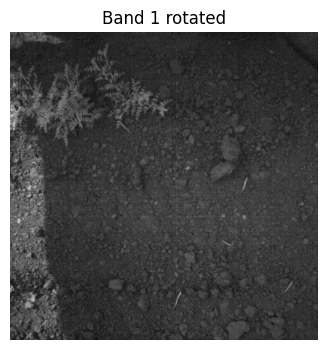

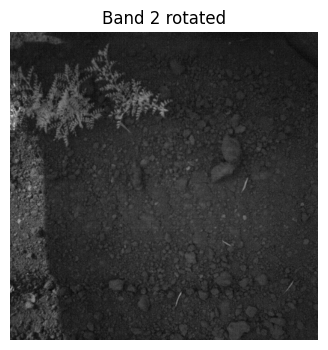

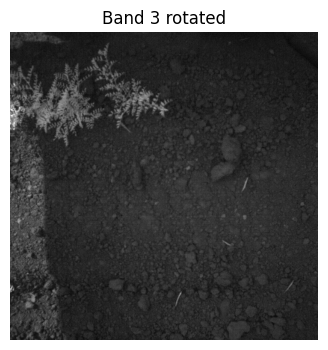

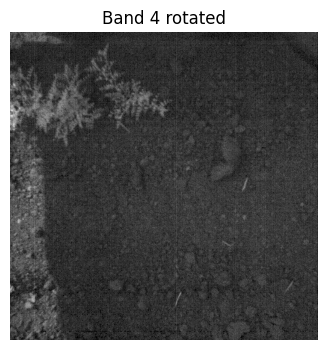

Saved bands:
/workspace/A4-RPiMS/vismatch-main/new_pair/band_1_rotated.png
/workspace/A4-RPiMS/vismatch-main/new_pair/band_2_rotated.png
/workspace/A4-RPiMS/vismatch-main/new_pair/band_3_rotated.png
/workspace/A4-RPiMS/vismatch-main/new_pair/band_4_rotated.png


In [4]:
!pip install tifffile

import tifffile as tiff
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

pair_folder = Path("/workspace/A4-RPiMS/vismatch-main/new_pair")

ms_path = pair_folder / "e0007_frame_ms_00444_Normal.tif"
rgb_path = pair_folder / "rgb-1775758717742527.jpg"

ms = tiff.imread(ms_path)

h, w = ms.shape
half_h = h // 2
half_w = w // 2

raw_bands = [
    ms[0:half_h, 0:half_w],       # band 1 top-left
    ms[0:half_h, half_w:w],       # band 2 top-right
    ms[half_h:h, 0:half_w],       # band 3 bottom-left
    ms[half_h:h, half_w:w]        # band 4 bottom-right
]

bands = []
band_paths = []

for i, band in enumerate(raw_bands):
    band_rot = np.rot90(band, k=-1)
    band_norm = cv2.normalize(band_rot, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    bands.append(band_norm)

    save_path = pair_folder / f"band_{i+1}_rotated.png"
    Image.fromarray(band_norm).save(save_path)
    band_paths.append(save_path)

    plt.figure(figsize=(4,4))
    plt.imshow(band_norm, cmap="gray")
    plt.title(f"Band {i+1} rotated")
    plt.axis("off")
    plt.show()

print("Saved bands:")
for p in band_paths:
    print(p)

### Match Image Pair

In [4]:
from pathlib import Path
from vismatch import get_matcher
from vismatch.viz import plot_matches

matcher = get_matcher("superpoint-lightglue")

pair_folder = Path("/workspace/A4-RPiMS/vismatch-main/new_pair")

rgb_path = pair_folder / "rgb-1775758717742527.jpg"

band_paths = sorted(pair_folder.glob("band_*_rotated.png"))

image_size = 512

for band_path in band_paths:
    img0 = matcher.load_image(rgb_path, resize=image_size)
    img1 = matcher.load_image(band_path, resize=image_size)

    result = matcher(img0, img1)

    num_inliers = result["num_inliers"]

    print(f"{band_path.name}: {num_inliers} inliers")

    plot_matches(img0, img1, result)

TypeError: 'type' object is not subscriptable